In [1]:
# ============================================================================
# ChemBERTa Embeddings + XGBoost/LightGBM for Quantum Yield Prediction
# ============================================================================

import pandas as pd
import torch
from transformers import AutoModel, AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.8.0
CUDA available: False


In [2]:
# ============================================================================
# LOAD DATA
# ============================================================================

df = pd.read_csv('datasets/msl_clean.csv')
df = df[['Chromophore', 'Solvent', 'Quantum yield']]

# Filter out NaN values
df = df.dropna(subset=['Quantum yield', 'Chromophore', 'Solvent'])
df = df[df['Quantum yield'] >= 0]

print(f"Dataset size: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nQuantum yield stats:")
print(df['Quantum yield'].describe())
df.head()

Dataset size: 13837
Columns: ['Chromophore', 'Solvent', 'Quantum yield']

Quantum yield stats:
count    13837.000000
mean         0.345025
std          0.307890
min          0.000000
25%          0.058400
50%          0.265000
75%          0.590000
max          1.000000
Name: Quantum yield, dtype: float64


,Chromophore,Solvent,Quantum yield
0,O=C([O-])c1ccccc1-c1c2ccc(=O)cc-2oc2cc([O-])ccc12,O,0.950
1,O=C([O-])c1ccccc1C1=c2cc3c4c(c2Oc2c1cc1c5c2CCC...,CO,1.000
2,O=C([O-])c1ccccc1-c1c2cc(Br)c(=O)c(Br)c-2oc2c(...,O,0.200
3,O=C([O-])c1ccccc1-c1c2cc(I)c(=O)c(I)c-2oc2c(I)...,O,0.020
4,O=C([O-])c1c(Cl)c(Cl)c(Cl)c(Cl)c1-c1c2cc(I)c(=...,O,0.018


In [3]:
# ============================================================================
# LOAD ChemBERTa MODEL
# ============================================================================

# ChemBERTa is a RoBERTa model pre-trained on SMILES strings
model_name = "seyonec/ChemBERTa-zinc-base-v1"

print(f"Loading ChemBERTa model: {model_name}")
chemberta_model = AutoModel.from_pretrained(model_name)
chemberta_tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Model loaded successfully!")
print(f"Hidden size: {chemberta_model.config.hidden_size}")

Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Model loaded successfully!
Hidden size: 768


In [4]:
# ============================================================================
# EMBEDDING CACHE AND FUNCTIONS
# ============================================================================

CACHE_FILE = "embedding caches/chemberta_cache.pt"

def load_cache():
    if os.path.exists(CACHE_FILE):
        return torch.load(CACHE_FILE)
    else:
        return {}

def save_cache(cache):
    os.makedirs(os.path.dirname(CACHE_FILE), exist_ok=True)
    torch.save(cache, CACHE_FILE)

def get_chemberta_embeddings(smiles_list, batch_size=32, max_length=128):
    """Get ChemBERTa embeddings for a list of SMILES strings."""
    
    device = torch.device("cpu")  # Use CPU to avoid MPS issues
    
    cache = load_cache()
    
    to_compute = [s for s in smiles_list if s not in cache]
    
    if len(to_compute) > 0:
        print(f"Computing {len(to_compute)} new ChemBERTa embeddings on {device}...")
        
        chemberta_model.to(device)
        chemberta_model.eval()
        
        with torch.no_grad():
            for i in range(0, len(to_compute), batch_size):
                batch = to_compute[i:i+batch_size]
                
                # Tokenize
                inputs = chemberta_tokenizer(
                    batch, 
                    padding=True, 
                    truncation=True,
                    max_length=max_length, 
                    return_tensors="pt"
                ).to(device)
                
                # Get embeddings
                outputs = chemberta_model(**inputs)
                
                # Use mean pooling of last hidden state
                attention_mask = inputs['attention_mask']
                hidden_states = outputs.last_hidden_state
                
                # Masked mean pooling
                mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
                sum_embeddings = torch.sum(hidden_states * mask_expanded, dim=1)
                sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
                embeddings = sum_embeddings / sum_mask
                
                for s, emb in zip(batch, embeddings):
                    cache[s] = emb.cpu()
                
                if (i + batch_size) % 500 == 0:
                    print(f"  Processed {min(i + batch_size, len(to_compute))}/{len(to_compute)}")
        
        save_cache(cache)
        print("Cache saved!")
    else:
        print("All embeddings already in cache.")
    
    ordered = [cache[s] for s in smiles_list]
    return torch.stack(ordered)

print("Embedding functions defined!")

Embedding functions defined!


In [ ]:

print("Computing chromophore embeddings...")
chrom_emb = get_chemberta_embeddings(df["Chromophore"].tolist())
print(f"Chromophore embeddings shape: {chrom_emb.shape}")

print("\nComputing solvent embeddings...")
solv_emb = get_chemberta_embeddings(df["Solvent"].tolist())
print(f"Solvent embeddings shape: {solv_emb.shape}")

# Combine embeddings
combined_emb = torch.cat([chrom_emb, solv_emb], dim=1)
print(f"\nCombined embedding shape: {combined_emb.shape}")

Computing chromophore embeddings...
All embeddings already in cache.
Chromophore embeddings shape: torch.Size([13837, 768])

Computing solvent embeddings...
All embeddings already in cache.
Solvent embeddings shape: torch.Size([13837, 768])

Combined embedding shape: torch.Size([13837, 1536])


In [ ]:
# Adding molecular descriptors + morgan fingerprints

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from tqdm import tqdm

def get_mol_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [0] * 10
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.NumAromaticRings(mol),
        rdMolDescriptors.CalcNumHeavyAtoms(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.NumValenceElectrons(mol),
    ]

def get_fingerprint(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return np.array(fp)

print("Computing molecular descriptors...")
chrom_descriptors = np.array([get_mol_descriptors(s) for s in tqdm(df['Chromophore'], desc="Chrom descriptors")])
solv_descriptors = np.array([get_mol_descriptors(s) for s in tqdm(df['Solvent'], desc="Solv descriptors")])

print("\nComputing Morgan fingerprints...")
chrom_fp = np.array([get_fingerprint(s) for s in tqdm(df['Chromophore'], desc="Chrom fingerprints")])
solv_fp = np.array([get_fingerprint(s) for s in tqdm(df['Solvent'], desc="Solv fingerprints")])

print(f"\nChromophore descriptors shape: {chrom_descriptors.shape}")
print(f"Solvent descriptors shape: {solv_descriptors.shape}")
print(f"Chromophore fingerprints shape: {chrom_fp.shape}")
print(f"Solvent fingerprints shape: {solv_fp.shape}")

desc_scaler = StandardScaler()
all_descriptors = np.concatenate([chrom_descriptors, solv_descriptors], axis=1)
all_descriptors_scaled = desc_scaler.fit_transform(all_descriptors)

all_fingerprints = np.concatenate([chrom_fp, solv_fp], axis=1)

X_embeddings = combined_emb.numpy() if hasattr(combined_emb, 'numpy') else np.array(combined_emb)
X_enhanced = np.concatenate([X_embeddings, all_descriptors_scaled, all_fingerprints], axis=1)

n_embeddings = X_embeddings.shape[1]
n_descriptors = all_descriptors_scaled.shape[1]
n_fingerprints = all_fingerprints.shape[1]

print(f"\n" + "="*60)
print("FEATURE SUMMARY")
print("="*60)
print(f"ChemBERTa embeddings:    {n_embeddings} features")
print(f"Molecular descriptors:   {n_descriptors} features (scaled)")
print(f"Morgan fingerprints:     {n_fingerprints} features")
print(f"{'='*60}")
print(f"TOTAL ENHANCED FEATURES: {X_enhanced.shape[1]}")
print("="*60)

Computing molecular descriptors...


Solv descriptors: 100%|██████████| 13837/13837 [00:22<00:00, 621.35it/s]



Computing Morgan fingerprints...


Solv fingerprints: 100%|██████████| 13837/13837 [00:13<00:00, 1022.61it/s]



Chromophore descriptors shape: (13837, 10)
Solvent descriptors shape: (13837, 10)
Chromophore fingerprints shape: (13837, 1024)
Solvent fingerprints shape: (13837, 1024)

FEATURE SUMMARY
ChemBERTa embeddings:    1536 features
Molecular descriptors:   20 features (scaled)
Morgan fingerprints:     2048 features
TOTAL ENHANCED FEATURES: 3604


In [ ]:
#Train/test/val split
X = X_enhanced
y = df["Quantum yield"].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42)

print(f"\nX shape: {X.shape}, y shape: {y.shape}")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Using ENHANCED features (embeddings + molecular descriptors + fingerprints)

X shape: (13837, 3604), y shape: (13837,)
X_train: (9685, 3604), y_train: (9685,)
X_val: (2768, 3604), y_val: (2768,)
X_test: (1384, 3604), y_test: (1384,)


In [ ]:
# Scaling features

n_emb = n_embeddings
n_desc = n_descriptors
n_fp = n_fingerprints


X_train_emb = X_train[:, :n_emb]
X_train_desc = X_train[:, n_emb:n_emb+n_desc]
X_train_fp = X_train[:, n_emb+n_desc:]

X_val_emb = X_val[:, :n_emb]
X_val_desc = X_val[:, n_emb:n_emb+n_desc]
X_val_fp = X_val[:, n_emb+n_desc:]

X_test_emb = X_test[:, :n_emb]
X_test_desc = X_test[:, n_emb:n_emb+n_desc]
X_test_fp = X_test[:, n_emb+n_desc:]

scaler_emb = StandardScaler()
X_train_emb_scaled = scaler_emb.fit_transform(X_train_emb)
X_val_emb_scaled = scaler_emb.transform(X_val_emb)
X_test_emb_scaled = scaler_emb.transform(X_test_emb)

X_train = np.concatenate([X_train_emb_scaled, X_train_desc, X_train_fp], axis=1)
X_val = np.concatenate([X_val_emb_scaled, X_val_desc, X_val_fp], axis=1)
X_test = np.concatenate([X_test_emb_scaled, X_test_desc, X_test_fp], axis=1)


print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")

Feature breakdown: 1536 embeddings + 20 descriptors + 2048 fingerprints = 3604 total
✓ Scaled features (embeddings scaled, descriptors pre-scaled, fingerprints binary)
X_train: (9685, 3604)
X_val: (2768, 3604)
X_test: (1384, 3604)


In [ ]:
#XGBoost

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=4,
    reg_lambda=2.0,
    reg_alpha=0.2,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    tree_method="hist"
)

eval_set = [(X_train, y_train), (X_val, y_val)]

print("Training XGBoost...")
xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
y_train_pred_xgb = xgb_model.predict(X_train)

print("\n" + "="*60)
print("XGBoost RESULTS (ChemBERTa + Descriptors + Fingerprints)")
print("="*60)
print(f"Train R²: {r2_score(y_train, y_train_pred_xgb):.4f}")
print(f"Test R²:  {r2_score(y_test, y_pred_xgb):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"Overfitting Gap: {r2_score(y_train, y_train_pred_xgb) - r2_score(y_test, y_pred_xgb):.4f}")

Training XGBoost...

XGBoost RESULTS (ChemBERTa + Descriptors + Fingerprints)
Train R²: 0.9872
Test R²:  0.6388
Test RMSE: 0.1857
Test MAE:  0.1320
Overfitting Gap: 0.3484


In [ ]:
#LightGBM


import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_lambda=2.0,
    reg_alpha=0.2,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

eval_set = [(X_train, y_train), (X_val, y_val)]

print("Training LightGBM...")
lgb_model.fit(
    X_train, y_train, 
    eval_set=eval_set, 
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# Evaluate
y_pred_lgb = lgb_model.predict(X_test)
y_train_pred_lgb = lgb_model.predict(X_train)

print("\n" + "="*60)
print("LightGBM RESULTS (ChemBERTa + Descriptors + Fingerprints)")
print("="*60)
print(f"Train R²: {r2_score(y_train, y_train_pred_lgb):.4f}")
print(f"Test R²:  {r2_score(y_test, y_pred_lgb):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lgb)):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_lgb):.4f}")
print(f"Overfitting Gap: {r2_score(y_train, y_train_pred_lgb) - r2_score(y_test, y_pred_lgb):.4f}")

Training LightGBM...

LightGBM RESULTS (ChemBERTa + Descriptors + Fingerprints)
Train R²: 0.9826
Test R²:  0.6301
Test RMSE: 0.1879
Test MAE:  0.1343
Overfitting Gap: 0.3525


MODEL COMPARISON (ChemBERTa + Descriptors + Fingerprints)
   Model  Train R²  Test R²  Test RMSE  Test MAE  Overfitting Gap
 XGBoost  0.987244 0.638805   0.185712  0.132040         0.348439
LightGBM  0.982558 0.630093   0.187938  0.134305         0.352466


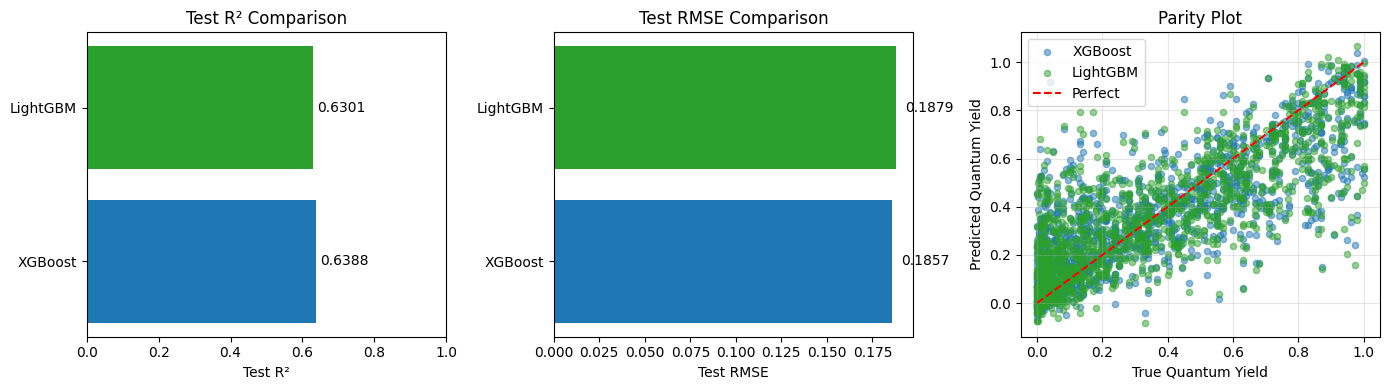


🏆 Best Model: XGBoost (Test R²: 0.6388)


In [11]:
# ============================================================================
# MODEL COMPARISON
# ============================================================================

print("="*70)
print("MODEL COMPARISON (ChemBERTa + Descriptors + Fingerprints)")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Train R²': [
        r2_score(y_train, y_train_pred_xgb),
        r2_score(y_train, y_train_pred_lgb)
    ],
    'Test R²': [
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_lgb)
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_lgb))
    ],
    'Test MAE': [
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_lgb)
    ]
})

comparison_df['Overfitting Gap'] = comparison_df['Train R²'] - comparison_df['Test R²']

print(comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = ['#1f77b4', '#2ca02c']

# Test R² comparison
axes[0].barh(comparison_df['Model'], comparison_df['Test R²'], color=colors)
axes[0].set_xlabel('Test R²')
axes[0].set_title('Test R² Comparison')
axes[0].set_xlim([0, 1])
for i, v in enumerate(comparison_df['Test R²']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')

# Test RMSE comparison
axes[1].barh(comparison_df['Model'], comparison_df['Test RMSE'], color=colors)
axes[1].set_xlabel('Test RMSE')
axes[1].set_title('Test RMSE Comparison')
for i, v in enumerate(comparison_df['Test RMSE']):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center')

# Parity plots
axes[2].scatter(y_test, y_pred_xgb, alpha=0.5, s=20, label='XGBoost', color=colors[0])
axes[2].scatter(y_test, y_pred_lgb, alpha=0.5, s=20, label='LightGBM', color=colors[1])
mn, mx = y_test.min(), y_test.max()
axes[2].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect')
axes[2].set_xlabel('True Quantum Yield')
axes[2].set_ylabel('Predicted Quantum Yield')
axes[2].set_title('Parity Plot')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Best model
best_idx = comparison_df['Test R²'].idxmax()
print(f"\n🏆 Best Model: {comparison_df.loc[best_idx, 'Model']} (Test R²: {comparison_df.loc[best_idx, 'Test R²']:.4f})")